In [1]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0


In [2]:
pip install pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
0        1000      M  39.0                59.9                    58.0   
1        1001      M  34.0                48.4                    37.0   
2        1002      F  40.0                70.5                    26.0   
3        1003      F  47.0                81.1                    30.0   
4        1004      F  33.0                42.1                    58.0   

   Cluster  
0        4  
1        4  
2        2  
3        0  
4        4  


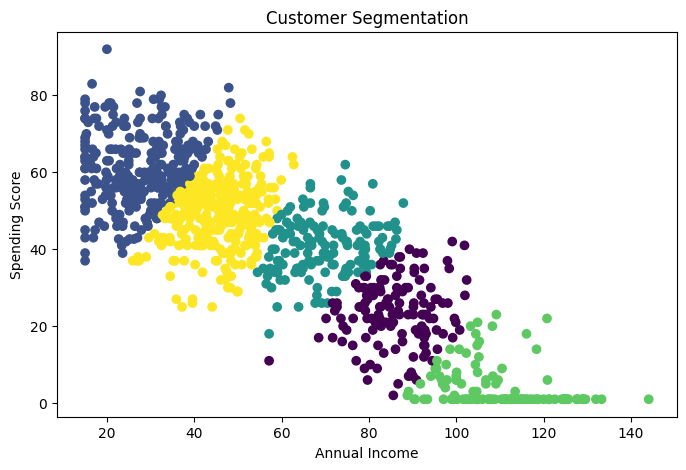

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv")

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

print(df.head())

plt.figure(figsize=(8,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

In [4]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster'],
      dtype='object')


In [5]:
print(df.isnull().sum())

CustomerID                0
Gender                    3
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
dtype: int64


In [7]:
df["Cluster"].value_counts()

Cluster
4    313
1    284
2    149
0    138
3    116
Name: count, dtype: int64

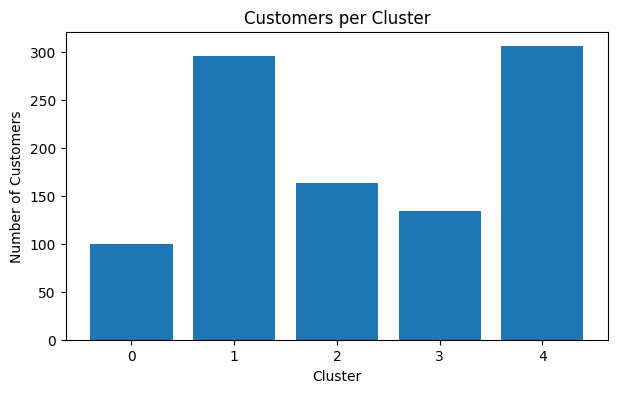

In [11]:
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7,4))

plt.bar(
    cluster_counts.index,
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customers per Cluster")

plt.show()